<a href="https://colab.research.google.com/github/Gchirico63/Didattica/blob/main/NonlinearExcitation/HermiteGaussianBeam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

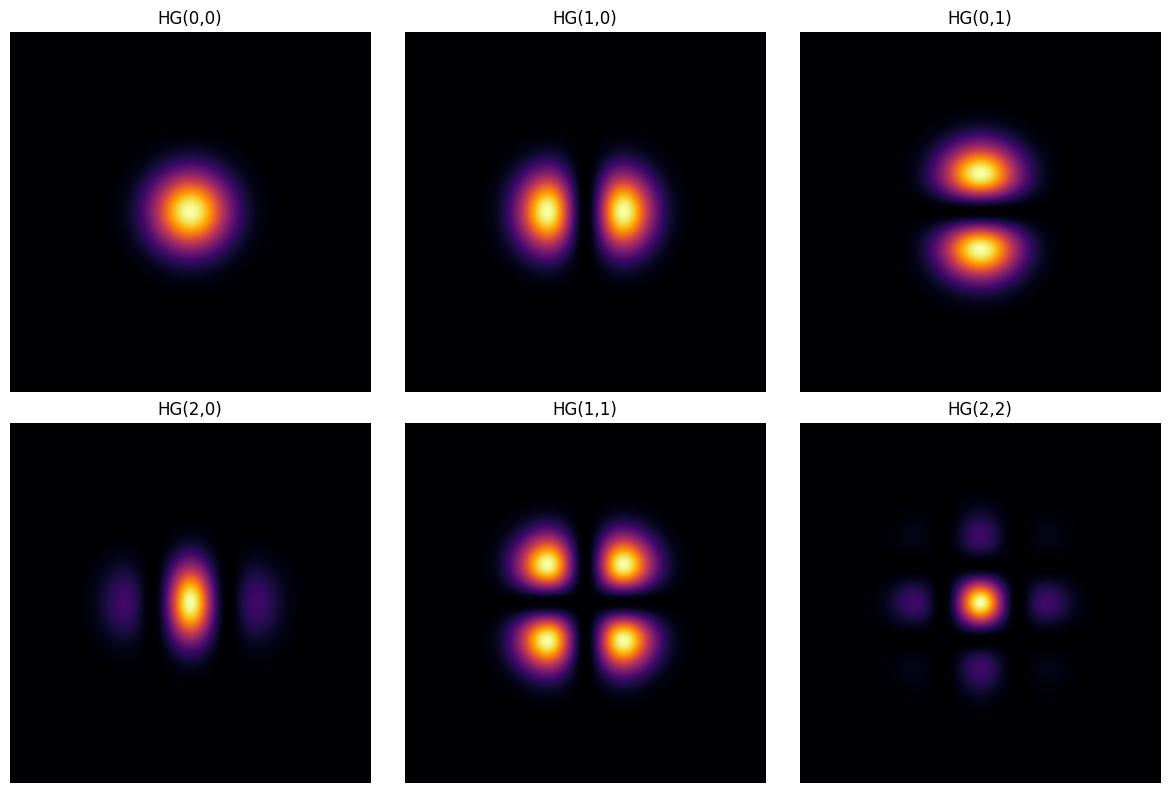

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hermite

# --- Grid definition ---
X0 = 10        # spatial extent
Np = 400       # number of points
x = np.linspace(-X0, X0, Np)
y = np.linspace(-X0, X0, Np)
xx, yy = np.meshgrid(x, y)

# --- Beam parameters ---
## all units in micrometers
w0 = 3.0       # beam waist

def HG_mode(m, n, xx, yy, w0):
    """
    Hermite-Gaussian mode HG_mn (intensity).
    """
    # Normalized coordinates
    X = xx / w0
    Y = yy / w0

    # Hermite polynomials
    Hm = hermite(m)
    Hn = hermite(n)

    # Field amplitude
    u = Hm(X) * Hn(Y) * np.exp(-(X**2 + Y**2))
    ### this is ok for the amplitude only

    # Intensity
    I = np.abs(u)**2
    return I

# --- Choose modes to plot ---
modes = [(0,0), (1,0), (0,1), (2,0), (1,1), (2,2)]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, (m, n) in zip(axes.flatten(), modes):
    I = HG_mode(m, n, xx, yy, w0)
    ax.imshow(I, cmap='inferno', extent=[-X0, X0, -X0, X0])
    ax.set_title(f"HG({m},{n})")
    ax.axis('off')

plt.tight_layout()
plt.show()
